<a href="https://colab.research.google.com/github/mglagan/mglagan.github.io/blob/main/SpatialRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatial Regression

This script explores spatial regression using TripAdvisor data from Metro Manila to analyze factors influencing vacation rental prices. It involves investigating linear relationships between attributes, creating spatial weights with the `pysal` library, examining spatial autocorrelation using Moran's I, and performing Ordinary Least Squares (OLS) and spatial regression modeling.

## Input Data

This exercise analyzes TripAdvisor rental rates in Metro Manila [TripAdvisor Scraper](https://apify.com/maxcopell/tripadvisor) using two datasets: the TripAdvisor Vacation Rental Dataset for rental rates and attributes, and OpenStreetMap data for street network information to include proximity variables and address spatial heterogeneity.

## Initialization

This section sets up the environment by installing and importing the necessary libraries.

In [ ]:
#Installing necessary libraries

!pip install osmnx
!pip install mapclassify
!pip install pysal
!pip install seaborn
!pip install libpysal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 834.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 15.3 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
    Uninstalling networkx-3.4.2:
      Successfully uninstalled networkx-3.4.2
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.0.1
    Uninstalling geopandas-1.0.1:
      Successfully uninstalled geopandas-1.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 17.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
#Importing modules for computing, mapping, and analysis

import geopandas as gpd
import pandas as pd
import osmnx as ox
import re
from shapely.geometry import Point
import matplotlib.pyplot as plt
from geopandas.tools import sjoin_nearest
import mapclassify as mc
import seaborn as sb
import libpysal as lp
import numpy as np
from libpysal.weights import DistanceBand
from esda.moran import Moran
from splot.esda import plot_moran
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pysal.model import spreg
from pysal.lib import weights
import pysal as ps

plt.style.use("dark_background")

In [ ]:
#Connecting to google drive, source of data

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preparing Data and Mapping Rental Prices

This task involves cleaning and processing TripAdvisor rental data by retaining key columns, converting it into a GeoDataFrame, and filtering it within Metro Manila's boundaries. The baseDailyRate is cleaned, the number of beds is extracted from bedroomInfo, and amenities are used to create explanatory variables. Additionally, distances to the nearest restaurants and primary roads are calculated. Missing values are handled, and the rental prices are visualized on a map.

In [ ]:
#Getting the boundary of Metro Manila
mm_bound = ox.geocode_to_gdf("Metro Manila")
mm = ox.project_gdf(mm_bound)

In [ ]:
#Reading tripadvisor data and retaining necessary columns into a dataframe
ta_df = pd.read_json('/content/drive/Shareddrives/GE 197 Spatial Data Science & Engineering/Exercise 1 Part 2/tripadvisor_gme222.json')
ta_df = ta_df[['amenities', 'bathCount', 'baseDailyRate', 'bedroomInfo', 'latitude', 'longitude']]

#Creating a geospatially referenced geodataframe from the tripadvisor dataframe
ta_df["geometry"] = gpd.points_from_xy(ta_df["longitude"], ta_df["latitude"])
ta_gdf = gpd.GeoDataFrame(ta_df, crs="EPSG:4326")
ta_gdf = ta_gdf.to_crs(mm.crs)
ta_gdf = ta_gdf[['amenities', 'bathCount', 'baseDailyRate', 'bedroomInfo', 'geometry']]

In [ ]:
#Getting tripadvisor dataset within Metro Manila
mm_geom = mm[['geometry']]
mm_data = gpd.sjoin(ta_gdf, mm_geom, how="left", predicate='within')
mm_data = mm_data[mm_data['index_right'].notna()] #keeping only rows with successful spatial join entry
mm_data = mm_data.drop(columns=['index_right']) #removes the column specificed for cleaner dataframe

In [ ]:
#Extracting numeric price data from the Metro Manila tripadvisor (MMTA) dataset

mm_data = mm_data.dropna(subset=['baseDailyRate']).copy() #removes rows with missing values under baseDailyRateColumn

#Creating a function to extract the amount specified from the argument or parameter called
def bdr_num(bdr):
    if isinstance(bdr, dict) and 'amount' in bdr:
        return bdr['amount']
    return None

mm_data['baseDailyRateNum'] = mm_data['baseDailyRate'].apply(bdr_num)

In [ ]:
#Creating a function to extract the number of bedroom form the parameter called
def br_num(br):
    if isinstance(br, str):
        numbers = re.findall(r'\d+', br) #find all numbers in each bedroomInfo
        if numbers:
            return sum(int(num) for num in numbers) #adds all the numbers
    return 0

mm_data['bed_count'] = mm_data['bedroomInfo'].apply(br_num)

In [ ]:
#Creating a function to check the presence or absence of Sauna in the data
def has_sauna(a):
    if 'Sauna' in a:
        return 1
    else:
        return 0

#Creating a function to check the presence or absence of Gym in the data
def has_gym(a):
    if 'Gym' in a:
        return 1
    else:
        return 0

#Applying the functions to create separate columns and add result
mm_data['sauna'] = mm_data['amenities'].apply(has_sauna)
mm_data['gym'] = mm_data['amenities'].apply(has_gym)

In [ ]:
#Loading road network data in Metro Manila from OSM

road_network = ox.graph_from_place('Metro Manila', network_type='all_public')
road_gdf = ox.graph_to_gdfs(road_network, nodes=False) #retains only lines
roads = road_gdf.to_crs(mm.crs)
roads.reset_index(inplace=True)
roads = roads[['geometry']]

In [ ]:
#Loading restaurant data in Metro Manila from OSM

restaurant_gdf = ox.geometries_from_place('Metro Manila', tags={'amenity': 'restaurant'})
restaurants= restaurant_gdf.to_crs(mm.crs)
restaurants = restaurants[restaurants.geometry.type == 'Point'] #retains only points
restaurants.reset_index(inplace=True)
restaurants = restaurants[['geometry']]

<ipython-input-25-3ae5fd3bd930>:3: FutureWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in the v2.0.0 release. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  restaurant_gdf = ox.geometries_from_place('Metro Manila', tags={'amenity': 'restaurant'})


In [ ]:
#Calculating the shorthest distance between each rental place to nearest restaurant

mm_data = sjoin_nearest(mm_data, restaurants, how='left', max_distance=10000, distance_col='restauDist')
mm_data = mm_data.drop(columns=['index_right'], errors='ignore') #removes the index_right column for data cleaning

In [ ]:
#Calculating the shorthest distance between each rental place to nearest road

mm_data = sjoin_nearest(mm_data, roads, how='left', max_distance=10000, distance_col='roadsDist')
mm_data = mm_data.drop(columns=['index_right'], errors='ignore') #removes the index_right column for data cleaning

In [ ]:
#Resetting mm_data index
mm_data.reset_index(inplace=True)

In [ ]:
mm_data.head()

,index,amenities,bathCount,baseDailyRate,bedroomInfo,geometry,baseDailyRateNum,bed_count,sauna,gym,restauDist,roadsDist
0,4080678,"[DVD player, Air conditioning, Pet friendly: N...",2,"{'amount': 74, 'currency': 'USD'}","2 Twins, 1 Queen",POINT (293241.836 1616098.333),74.0,3,0,1,41.201901,8.166243
1,6358484,"[DVD player, Air conditioning, Pet friendly: N...",1,"{'amount': 68, 'currency': 'USD'}","1 Queen, 1 Sofa",POINT (293287.623 1615905.724),68.0,2,0,1,20.134841,1.076012
2,13124595,"[Air conditioning, Pet friendly: NO, Children'...",1,"{'amount': 46, 'currency': 'USD'}","1 Twin, 1 Full",POINT (290474.655 1617547.025),46.0,2,0,1,10.040884,3.724763
3,13124595,"[Air conditioning, Pet friendly: NO, Children'...",1,"{'amount': 46, 'currency': 'USD'}","1 Twin, 1 Full",POINT (290474.655 1617547.025),46.0,2,0,1,10.040884,3.724763
4,7043252,"[DVD player, Air conditioning, Pet friendly: N...",1,"{'amount': 41, 'currency': 'USD'}","1 Sofa, 1 Full",POINT (287709.124 1621528.452),41.0,2,0,1,261.587237,18.602838


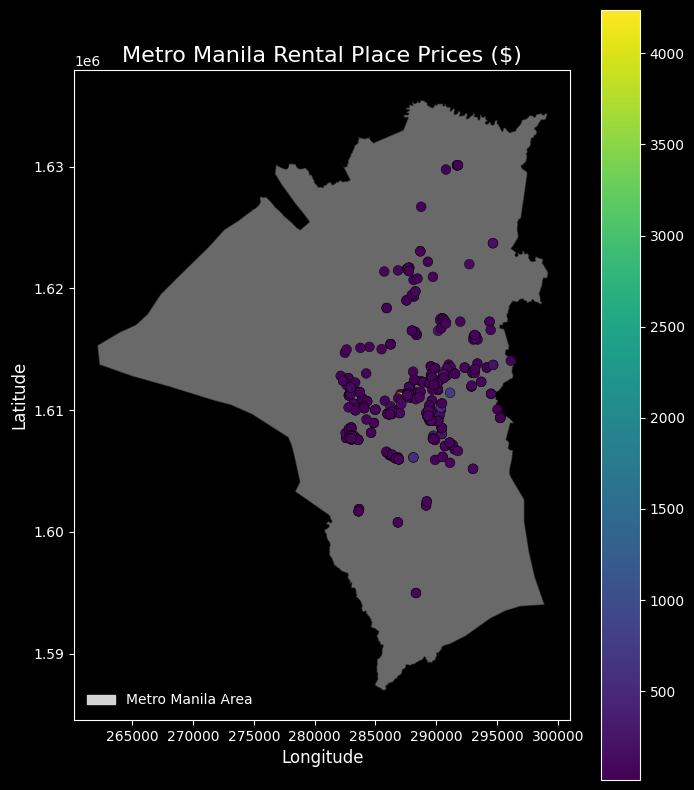

In [ ]:
#Mapping the rental place prices

fig, price = plt.subplots(figsize=(8, 10))

mm.plot(ax=price, color='lightgray', alpha=0.5, edgecolor='black', linewidth=1) #plot Metro Manila boundary
mm_data.plot(ax=price, column='baseDailyRateNum', cmap='viridis', legend=True, s=50, alpha=1, edgecolor='black', linewidth=0.3) #plots data from specified column

#Setting map labels and legends
plt.title('Metro Manila Rental Place Prices ($)', fontsize=16)
price.set_xlabel('Longitude', fontsize=12)
price.set_ylabel('Latitude', fontsize=12)
metro = mpatches.Patch(color='lightgray', label='Metro Manila Area')
price.legend(handles=[metro], loc='lower left',frameon=False)

plt.show()

## Creating a Correlation Matrix

This task involves calculating the correlation matrix between the selected variables in the TripAdvisor data, rounding the values to two decimals, and visualizing it as a heatmap using Seaborn's `heatmap()` function. The correlation values are annotated on the plot to help assess linear relationships between variables, especially price.


In [ ]:
#Specifying the variables
vars = ['baseDailyRateNum','bathCount', 'bed_count', 'sauna', 'gym', 'restauDist', 'roadsDist']

In [ ]:
#Finding the correlation of each variable to others
correlation_matrix = mm_data[vars].corr()
correlation_matrix = correlation_matrix.round(2)
correlation_matrix

,baseDailyRateNum,bathCount,bed_count,sauna,gym,restauDist,roadsDist
baseDailyRateNum,1.00,0.13,-0.01,-0.03,0.07,-0.05,-0.04
bathCount,0.13,1.00,0.34,-0.01,-0.09,0.11,0.03
bed_count,-0.01,0.34,1.00,-0.09,0.07,0.11,-0.04
sauna,-0.03,-0.01,-0.09,1.00,0.36,-0.12,-0.05
gym,0.07,-0.09,0.07,0.36,1.00,-0.11,-0.03
restauDist,-0.05,0.11,0.11,-0.12,-0.11,1.00,0.53
roadsDist,-0.04,0.03,-0.04,-0.05,-0.03,0.53,1.00


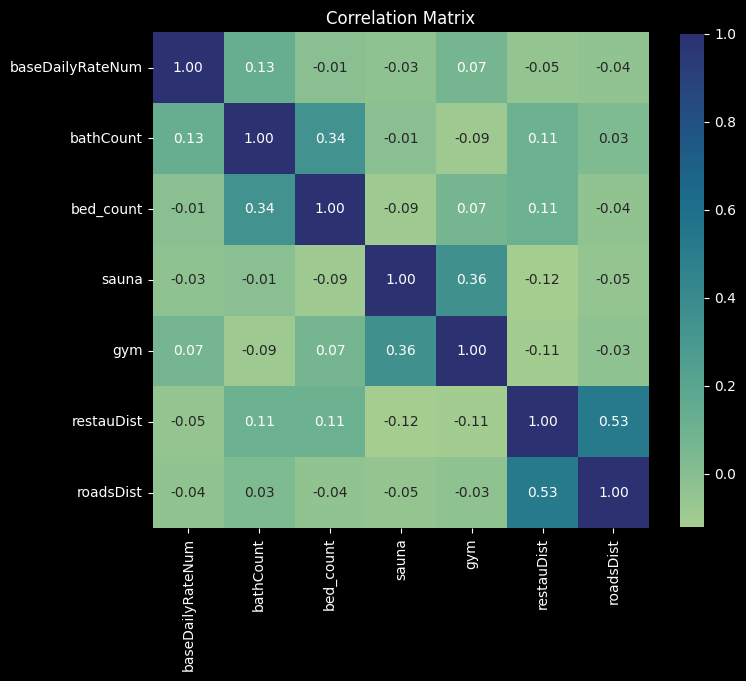

In [ ]:
#Visualizing the correlation matrix using seaborn's heatmap()

plt.figure(figsize=(8, 8))
sb.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='crest', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()

## Is there spatial autocorrelation in the price values?

This task involves investigating spatial autocorrelation in the price variable using Moran's I. First, it creates spatial weights based on a 2 km distance threshold using the `pysal` library. Then, it calculates Moran's I for the price variable and interpret the result. Finally, it visualizes the spatial autocorrelation with a Moran plot.

In [ ]:
coordinates = np.array([[geom.x, geom.y] for geom in mm_data.geometry]) #extracting the x,y coordinates of mm_data points
w = DistanceBand(coordinates, threshold=2000, binary=False) #creating spatial weights

In [ ]:
#Calculating the global moran's I
moran = Moran(mm_data['baseDailyRateNum'], w)
print("The Global Moran's I is", moran.I)

The Global Moran's I is 0.005642447518698172


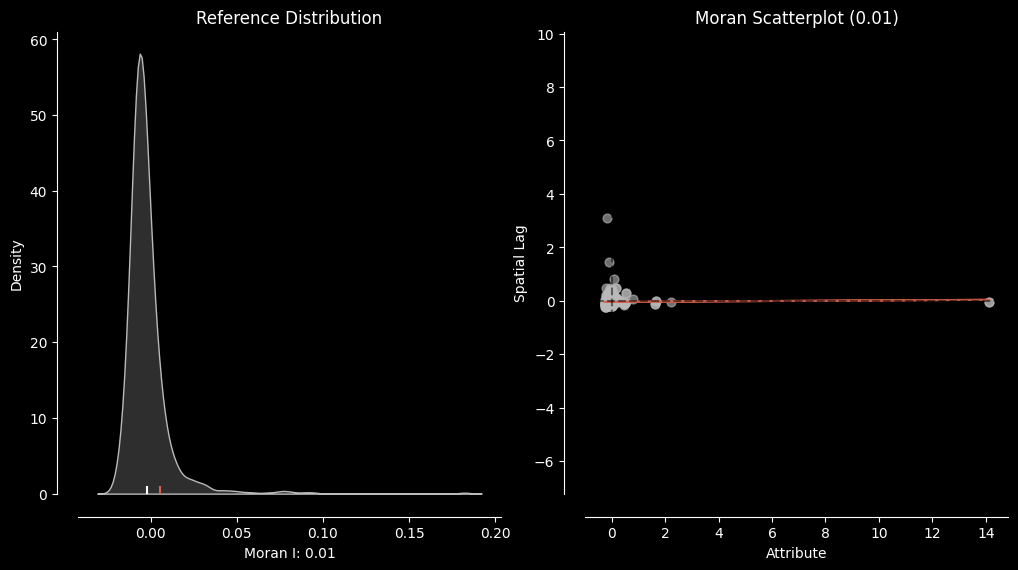

In [ ]:
#Creating a Moran Plot
plot_moran(moran, zstandard=True, figsize=(12, 6))
plt.show()

## Spatial regression

This task involves log-transforming variables for linearity and conducting three regression models: a standard OLS model, an OLS model with proximity variables for spatial heterogeneity, and a Spatial Lag model considering neighboring area prices.



### Ordinary Least Squares (OLS)

This task involves log-transforming the price variable and storing it as "log_price." It then runs an Ordinary Least Squares (OLS) regression with "log_price" as the dependent variable and the number of bathrooms, number of beds, and amenity-related variables as explanatory variables. Finally, it prints the summary of the regression model.


In [ ]:
#Performing logarithmic transformation on the price
mm_data['log_price'] = np.log(mm_data['baseDailyRateNum'])

In [ ]:
#Defining independent and dependent variables
explanatory_vars1 = ['bathCount', 'bed_count', 'sauna', 'gym']
x = mm_data[explanatory_vars1].values
y = mm_data['log_price'].values

In [ ]:
#Creating regression model
m1 = spreg.OLS(y, x, w=w, name_y='log_price', name_x = explanatory_vars1, spat_diag=True, moran=True)
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:         425
Mean dependent var  :      4.1177                Number of Variables   :           5
S.D. dependent var  :      0.6172                Degrees of Freedom    :         420
R-squared           :      0.3001
Adjusted R-squared  :      0.2935
Sum squared residual:      113.04                F-statistic           :     45.0270
Sigma-square        :       0.269                Prob(F-statistic)     :   1.822e-31
S.E. of regression  :       0.519                Log likelihood        :    -321.626
Sigma-square ML     :       0.266                Akaike info criterion :     653.252
S.E of regression ML:      0.5157                Schwarz criterion     :     673.512

------------------------------------------------------------

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Spatial Heterogeneity

This task incorporates spatial effects by adding proximity variables (distance to restaurant and distance to the nearest highway) into the regression model. Then, it performs an OLS regression with "log_price" as the dependent variable and the proximity variables as explanatory variables. Lastly, it prints the summary of the regression model.

In [ ]:
#Defining independent and dependent variables
explanatory_vars2 = ['bathCount', 'bed_count', 'sauna', 'gym', 'restauDist', 'roadsDist']
x = mm_data[explanatory_vars2].values
y = mm_data['log_price'].values

In [ ]:
#Creating regression model
m2 = spreg.OLS(y, x, w=w, name_y='log_price', name_x = explanatory_vars2, spat_diag=True, moran=True)
print(m2.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   log_price                Number of Observations:         425
Mean dependent var  :      4.1177                Number of Variables   :           7
S.D. dependent var  :      0.6172                Degrees of Freedom    :         418
R-squared           :      0.3115
Adjusted R-squared  :      0.3016
Sum squared residual:     111.203                F-statistic           :     31.5195
Sigma-square        :       0.266                Prob(F-statistic)     :   2.907e-31
S.E. of regression  :       0.516                Log likelihood        :    -318.144
Sigma-square ML     :       0.262                Akaike info criterion :     650.288
S.E of regression ML:      0.5115                Schwarz criterion     :     678.653

------------------------------------------------------------

### Spatial Lag Model

This task focuses on introducing spatial effects into the dependent variable by conducting a spatial lag model. It runs a spatial two-stage least squares regression (spatial lag model) with the same explanatory variables as in the above tasks (number of beds, number of baths, amenities). Finally, it prints the summary of the regression model.

In [ ]:
#Defining independent and dependent variables
explanatory_vars3 = ['bathCount', 'bed_count', 'sauna', 'gym']
x = mm_data[explanatory_vars3].values
y = mm_data['log_price'].values

In [ ]:
#Creating regression model with spatial lag effect
m3 = spreg.GM_Lag(y, x, w=w, name_y='ln(price)', name_x = explanatory_vars3, spat_diag=True)
print(m3.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: SPATIAL TWO STAGE LEAST SQUARES
--------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   ln(price)                Number of Observations:         425
Mean dependent var  :      4.1177                Number of Variables   :           6
S.D. dependent var  :      0.6172                Degrees of Freedom    :         419
Pseudo R-squared    :      0.3311
Spatial Pseudo R-squared:  0.3017

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         2.99329         0.24346        12.29472         0.00000
           bathCount         0.58454         0.04359        13.40845         0.00000
           bed_count        -0.03471      